# Im(r_p) Dispersion Maps: Extracted q_p vs Simulated Multilayer Reflection

For each of the 3 linecut datasets, compute Im(r_p)(q, omega) for the appropriate
layer stack (graphene-only on SiO2/Si for graphene_3x1_manual; MoO3/graphene/SiO2/Si
for graphene_4x1_manual's lp1="edge"/lp2="interior") using
`snippet.nearfield.rp_schematic` (same tool `response_Shizhe.ipynb` uses for doped
graphene/CIPS, and the same `NearFieldOptics.Materials.AnisotropicMaterial` +
`LayeredMediaTM` engine `CrSBr_Rp_calculation` uses for CrSBr), and overlay the
q_p extracted this session (CHT/Hankel/1-sqrtx/FFT, from
`data/fit_results_graphene_*.pkl`) as scatter points on top.

E_F is fit **independently per method per dataset** (12 fits total) rather than
one E_F per dataset -- CHT/Hankel/1-sqrtx/FFT don't extract exactly the same q_p
at a given wn, so forcing one E_F onto all 4 makes 3 of the 4 visibly miss the
ridge. gamma=20cm-1 is kept fixed (per the reference figures) for all fits.

In [1]:
import sys, os
sys.path.append('.')
sys.path.append('/Users/shizhe/envsetting')
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from snippet.nearfield import rp_schematic
from NearFieldOptics import Materials as M

plt.rcParams.update({
    'font.size': 12, 'font.family': 'Arial',
    'axes.linewidth': 1.5, 'xtick.major.width': 1.5, 'ytick.major.width': 1.5,
    'xtick.direction': 'in', 'ytick.direction': 'in', 'xtick.top': True,
    'ytick.right': True
})

SAVE_DIR = 'figures/rp_dispersion'
os.makedirs(SAVE_DIR, exist_ok=True)
GAMMA = 20  # cm^-1, fixed for all fits per the reference figures


<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "Bi2Se3_epsilon.pickle"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "PMMA_epsilon.pickle"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "sio2_300nm_extracted_epsilon_cone_A=2a.pickle"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "TaS2_eps_230K.csv"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "TaS2_eps_30K.csv"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "Erik_BSTS_epsilon.pickle"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "VO2_295K.csv"...
<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "VO2_360K.csv"...
<material_types.Ta

## 1. Materials

MoO3: anisotropic phonon material, in-plane (x=y) and out-of-plane (z) LO/TO modes from https://onlinelibrary.wiley.com/doi/abs/10.1002/adma.201908176. `phonon_params` per axis is a list of `(omega_LO, gamma_LO, omega_TO, gamma_TO)` tuples -- the user's table is already in that order, no reordering needed (confirmed against `NearFieldOptics.Materials.material_types.get_phonons`).

In [2]:
# MoO3: eps_infinity=[xx, yy, zz], phonon_params=[modes_x, modes_y, modes_z]
# in-plane (x=y): wLO=972 gLO=4 wTO=820 gTO=4  |  out-of-plane (z): wLO=1004 gLO=2 wTO=958 gTO=2
modes_xy = [(972, 4, 820, 4)]
modes_z = [(1004, 2, 958, 2)]
MoO3 = M.AnisotropicMaterial(eps_infinity=[4, 5.2, 2.4], phonon_params=[modes_xy, modes_xy, modes_z])

# SiO2 300nm on Si substrate -- shared by both stacks below
materials_3x1 = {'SiO2': M.SiO2_300nm}
materials_4x1 = {'SiO2': M.SiO2_300nm, 'MoO3': MoO3}
SUBS = M.Si

stack_3x1 = ['graphene', ('SiO2', 300)]
stack_4x1 = [('MoO3', 4.2), 'graphene', ('SiO2', 300)]


## 2. Build overlay points from the fitted q_p (this session's pkl results)

`rp_schematic(..., pts=pts_dict, pts_chn='cht')` expects `pts_dict['cht_qp']` to be a DataFrame with `q(cm-1)` and `w(cm-1)` columns.

In [3]:
METHODS = ['cht', 'hankel', 'sqrtx', 'fft']

def build_pts(pkl_path):
    """data/fit_results_graphene_*.pkl -> {'cht_qp': df, 'hankel_qp': df, 'sqrtx_qp': df, 'fft_qp': df}"""
    with open(pkl_path, 'rb') as f:
        pkl = pickle.load(f)
    out = {}
    for m in METHODS:
        rows = []
        for wn_key, results in pkl.items():
            q_1e5 = results[m]['q_p_1e5cm-1']
            if q_1e5 is None:
                continue
            rows.append({'w(cm-1)': int(wn_key.replace('cm-1', '')), 'q(cm-1)': q_1e5 * 1e5})
        out[f'{m}_qp'] = pd.DataFrame(rows).sort_values('w(cm-1)').reset_index(drop=True)
    return out

pts_3x1 = build_pts('data/fit_results_graphene_3x1_manual.pkl')
pts_lp1 = build_pts('data/fit_results_graphene_4x1_lp1.pkl')
pts_lp2 = build_pts('data/fit_results_graphene_4x1_lp2.pkl')

for name, pts in [('3x1_manual', pts_3x1), ('4x1_lp1 (edge)', pts_lp1), ('4x1_lp2 (interior)', pts_lp2)]:
    print(name, '-- cht points:', len(pts['cht_qp']), 'wn range:',
          pts['cht_qp']['w(cm-1)'].min(), '-', pts['cht_qp']['w(cm-1)'].max())


3x1_manual -- cht points: 15 wn range: 860 - 1000
4x1_lp1 (edge) -- cht points: 15 wn range: 860 - 1000
4x1_lp2 (interior) -- cht points: 15 wn range: 860 - 1000


## 3. Per-method E_F fit

For a trial E_F, evaluate Im(r_p) at each data point's exact (q, w) (diagonal of the frequency x q grid `reflection_p` returns) and sum -- this is maximized when the data points sit on the bright dispersion ridge. `scipy.optimize.minimize_scalar` (bounded, 1D) finds the E_F that maximizes this sum. gamma stays fixed at `GAMMA` throughout.

In [4]:
def build_tm_layers(stack, materials, Ef, gamma):
    Efcm = Ef * 8065.5
    graphene = M.SingleLayerGraphene(chemical_potential=Efcm, gamma=gamma)
    tm_layers = []
    for item in stack:
        if isinstance(item, str) and item.lower() == 'graphene':
            tm_layers.append(graphene)
        else:
            name, thickness_nm = item
            tm_layers.append((materials[name], thickness_nm * 1e-7))
    return tm_layers

def fit_Ef(stack, materials, subs, w_data, q_data, gamma=GAMMA, ef_bounds=(0.1, 1.5)):
    w_data = np.asarray(w_data, dtype=float)
    q_data = np.asarray(q_data, dtype=float)

    def neg_score(Ef):
        layersTM = M.LayeredMediaTM(*build_tm_layers(stack, materials, Ef, gamma), exit=subs)
        rp_grid = np.asarray(layersTM.reflection_p(w_data, q=q_data))
        return -float(np.sum(np.imag(np.diag(rp_grid))))

    res = minimize_scalar(neg_score, bounds=ef_bounds, method='bounded')
    return float(res.x)

def fit_all_methods(stack, materials, pts):
    ef_by_method = {}
    for m in METHODS:
        df = pts[f'{m}_qp']
        ef_by_method[m] = fit_Ef(stack, materials, SUBS, df['w(cm-1)'].values, df['q(cm-1)'].values)
    return ef_by_method

ef_3x1 = fit_all_methods(stack_3x1, materials_3x1, pts_3x1)
ef_lp1 = fit_all_methods(stack_4x1, materials_4x1, pts_lp1)
ef_lp2 = fit_all_methods(stack_4x1, materials_4x1, pts_lp2)

print('E_F (eV), 3x1_manual (Gr/SiO2/Si):     ', {k: round(v, 3) for k, v in ef_3x1.items()})
print('E_F (eV), 4x1 lp1 (MoO3 edge):         ', {k: round(v, 3) for k, v in ef_lp1.items()})
print('E_F (eV), 4x1 lp2 (MoO3 interior):     ', {k: round(v, 3) for k, v in ef_lp2.items()})


E_F (eV), 3x1_manual (Gr/SiO2/Si):      {'cht': 0.507, 'hankel': 0.497, 'sqrtx': 0.498, 'fft': 0.647}
E_F (eV), 4x1 lp1 (MoO3 edge):          {'cht': 0.771, 'hankel': 0.773, 'sqrtx': 0.768, 'fft': 0.704}
E_F (eV), 4x1 lp2 (MoO3 interior):      {'cht': 0.723, 'hankel': 0.915, 'sqrtx': 0.96, 'fft': 0.51}


## 4. graphene_3x1_manual -- Gr/SiO2(300nm)/Si (no MoO3)

Saved figures/rp_dispersion/graphene_3x1_manual_rp_dispersion.png


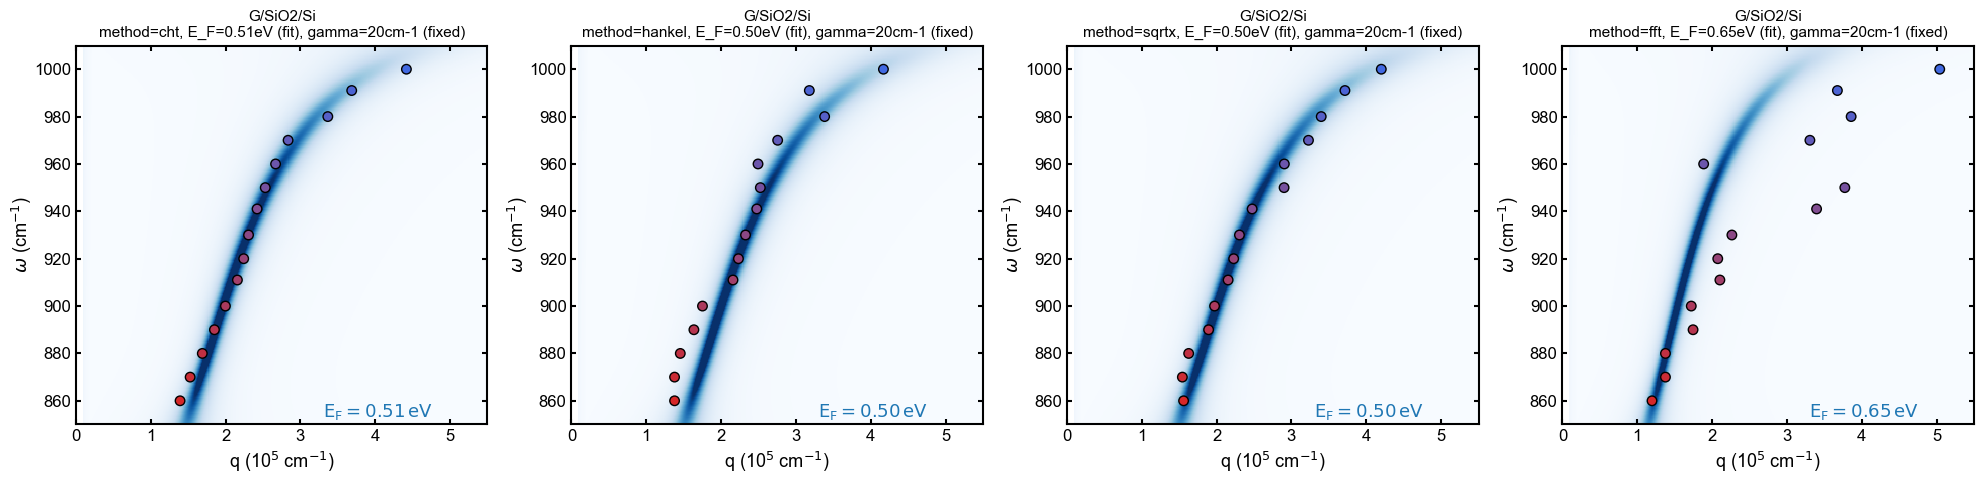

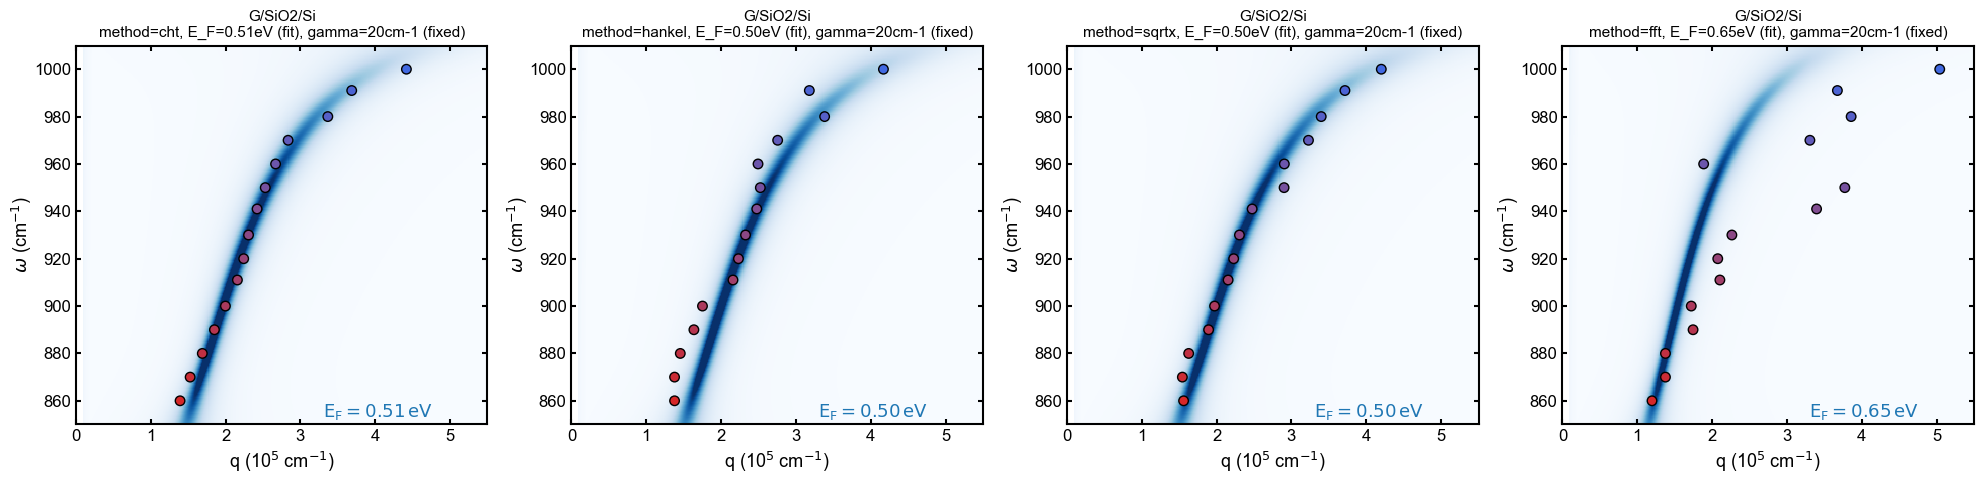

In [5]:
FREQS = np.linspace(850, 1010, 300)
QS = np.linspace(1e4, 5.5e5, 400)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, method in zip(axes, METHODS):
    rp_schematic(stack_3x1, materials_3x1, subs=SUBS, freqs=FREQS, qs=QS,
                 Ef=ef_3x1[method], gamma=GAMMA, figAx=(fig, ax), vmin=0, vmax=8,
                 pts=pts_3x1, pts_chn=method, show_Ef=True, ytickspacing=20)
    ax.set_title(f'G/SiO2/Si\nmethod={method}, E_F={ef_3x1[method]:.2f}eV (fit), gamma={GAMMA}cm-1 (fixed)', fontsize=11)

fig.tight_layout()
fig.savefig(f'{SAVE_DIR}/graphene_3x1_manual_rp_dispersion.png', dpi=200, bbox_inches='tight')
print(f'Saved {SAVE_DIR}/graphene_3x1_manual_rp_dispersion.png')
fig


## 5. graphene_4x1_manual lp1 ("MoO3 edge") -- MoO3(4.2nm)/Gr/SiO2(300nm)/Si

Saved figures/rp_dispersion/graphene_4x1_lp1_edge_rp_dispersion.png


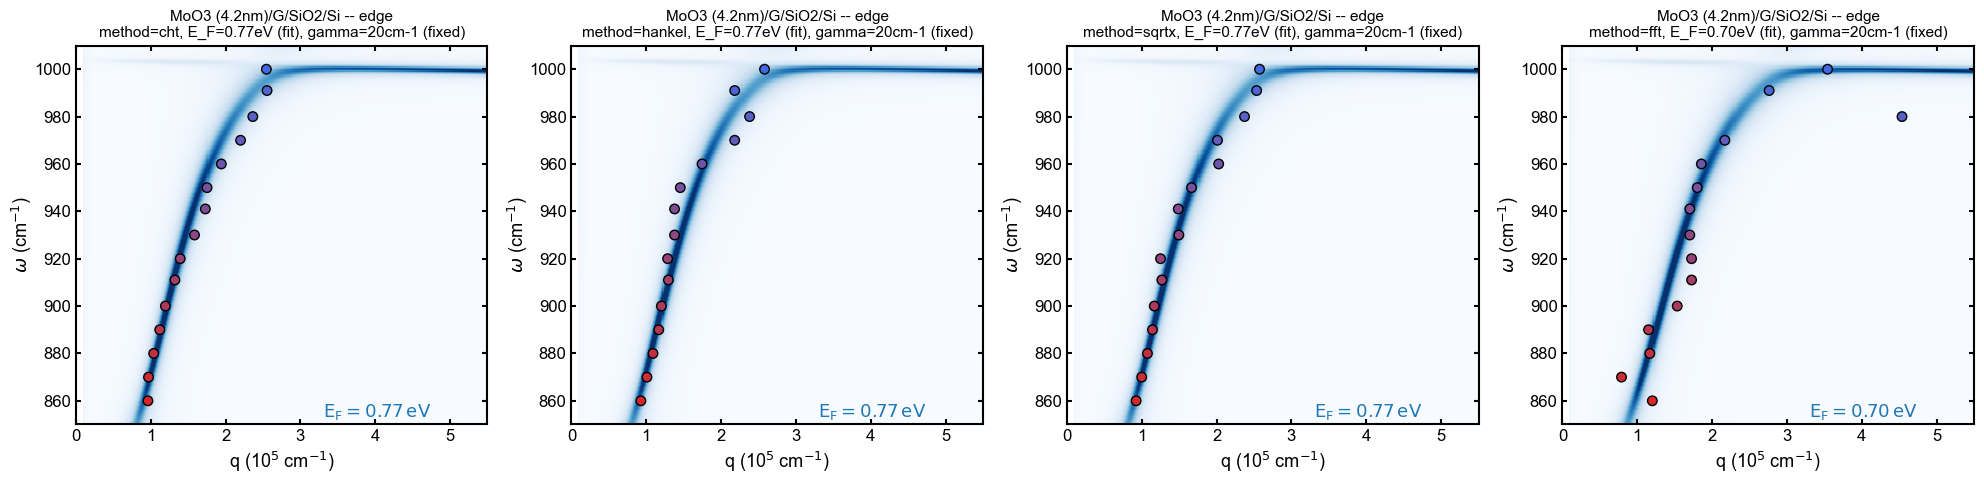

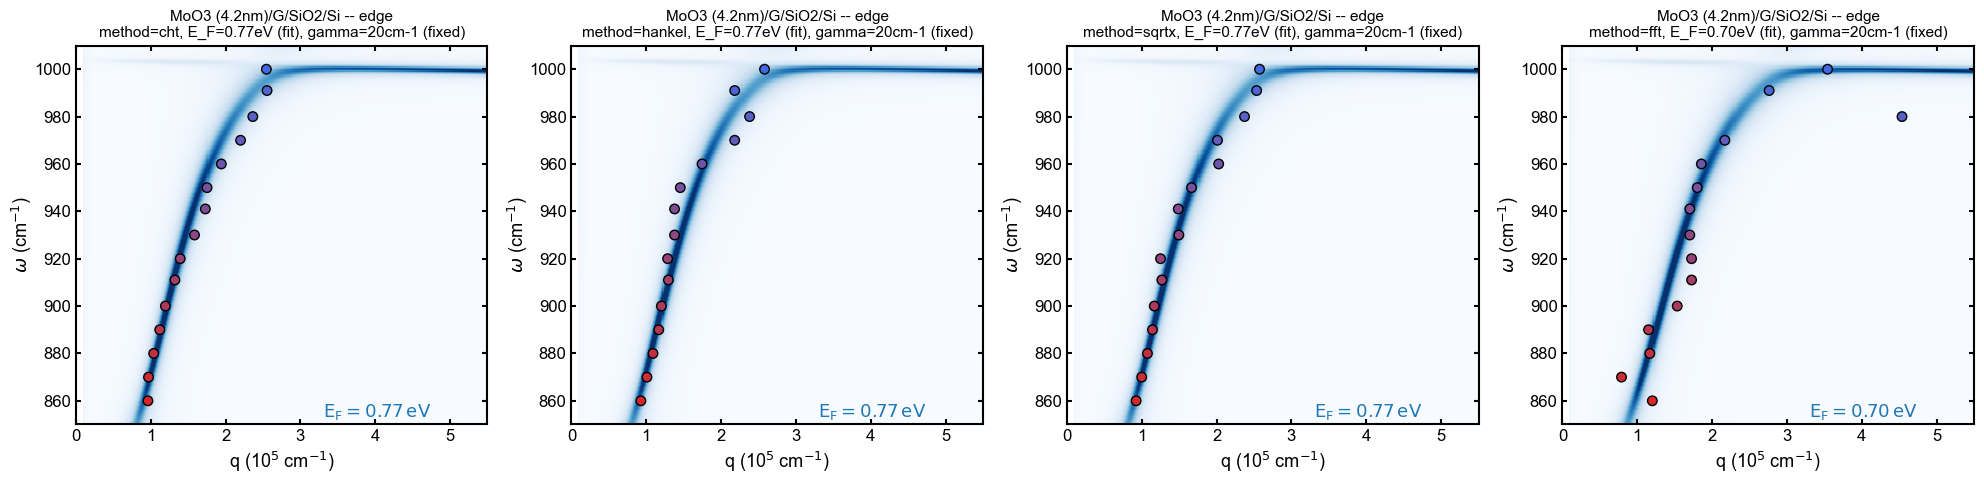

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, method in zip(axes, METHODS):
    rp_schematic(stack_4x1, materials_4x1, subs=SUBS, freqs=FREQS, qs=QS,
                 Ef=ef_lp1[method], gamma=GAMMA, figAx=(fig, ax), vmin=0, vmax=8,
                 pts=pts_lp1, pts_chn=method, show_Ef=True, ytickspacing=20)
    ax.set_title(f'MoO3 (4.2nm)/G/SiO2/Si -- edge\nmethod={method}, E_F={ef_lp1[method]:.2f}eV (fit), gamma={GAMMA}cm-1 (fixed)', fontsize=11)

fig.tight_layout()
fig.savefig(f'{SAVE_DIR}/graphene_4x1_lp1_edge_rp_dispersion.png', dpi=200, bbox_inches='tight')
print(f'Saved {SAVE_DIR}/graphene_4x1_lp1_edge_rp_dispersion.png')
fig


## 6. graphene_4x1_manual lp2 ("MoO3 interior") -- MoO3(4.2nm)/Gr/SiO2(300nm)/Si

Saved figures/rp_dispersion/graphene_4x1_lp2_interior_rp_dispersion.png


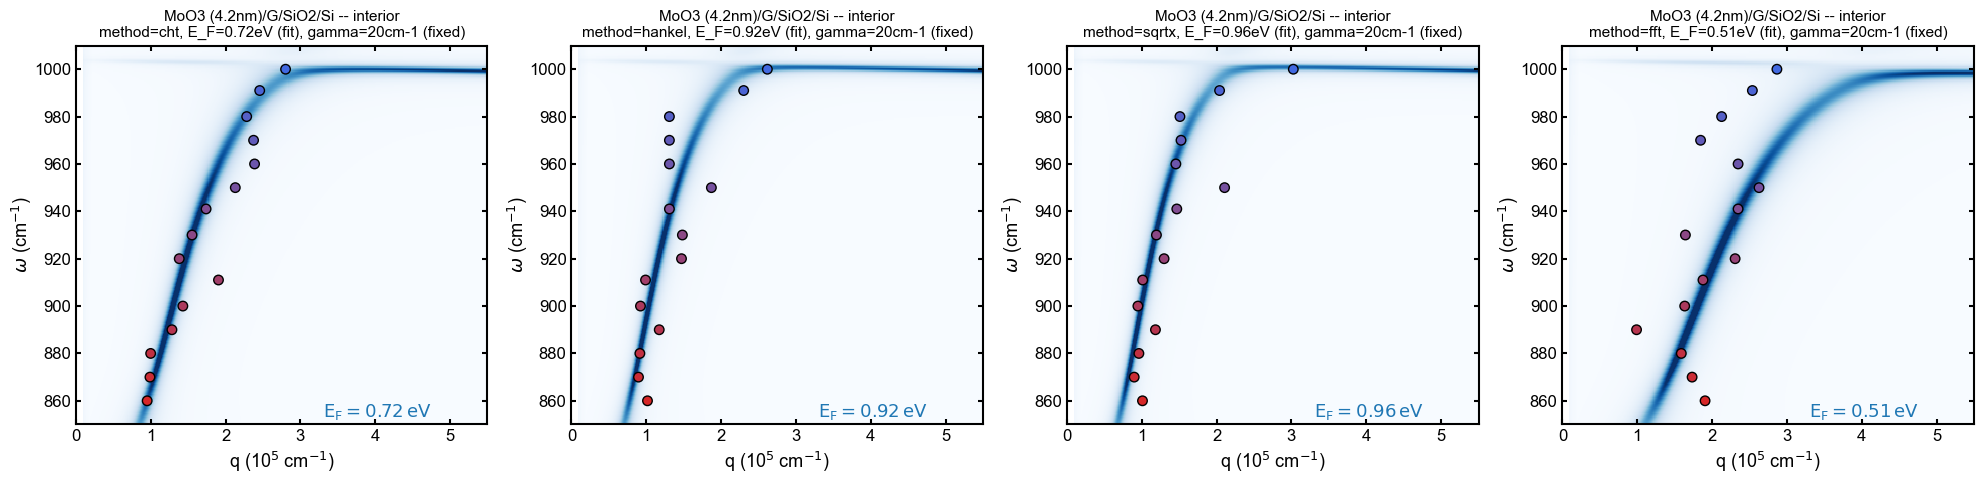

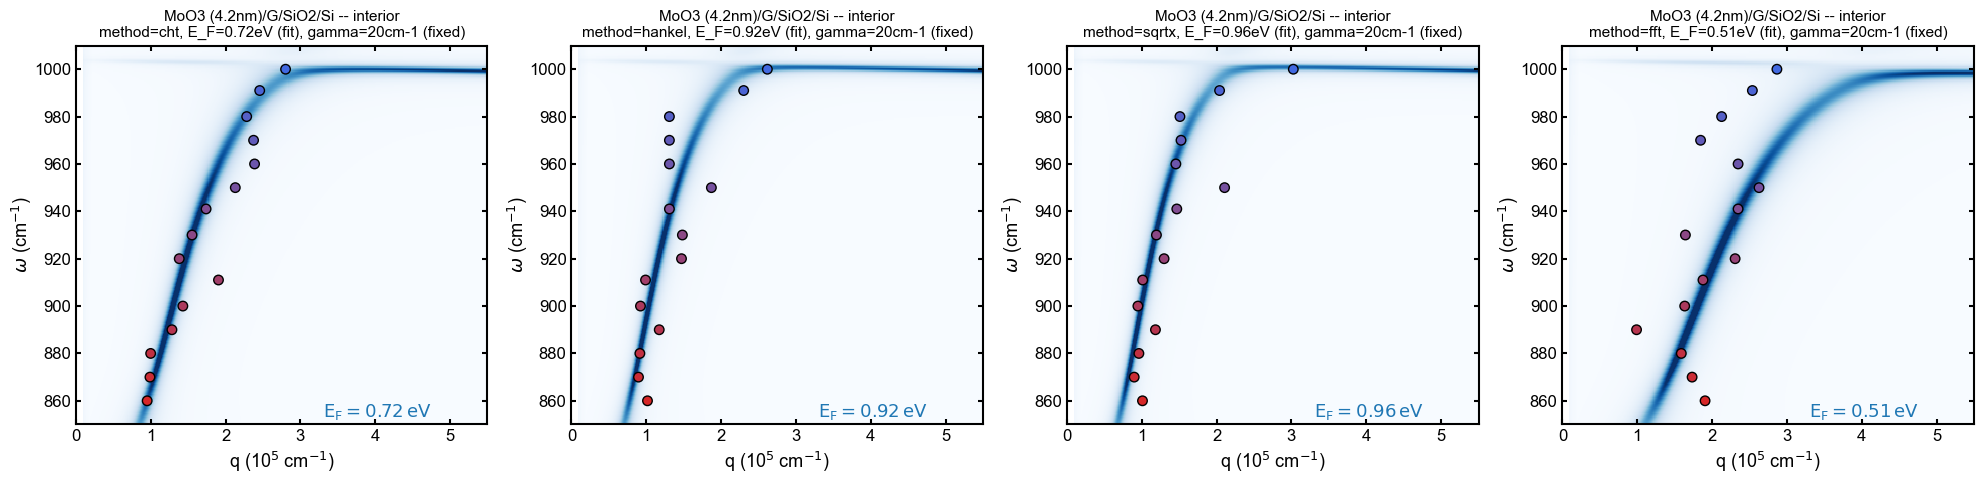

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, method in zip(axes, METHODS):
    rp_schematic(stack_4x1, materials_4x1, subs=SUBS, freqs=FREQS, qs=QS,
                 Ef=ef_lp2[method], gamma=GAMMA, figAx=(fig, ax), vmin=0, vmax=8,
                 pts=pts_lp2, pts_chn=method, show_Ef=True, ytickspacing=20)
    ax.set_title(f'MoO3 (4.2nm)/G/SiO2/Si -- interior\nmethod={method}, E_F={ef_lp2[method]:.2f}eV (fit), gamma={GAMMA}cm-1 (fixed)', fontsize=11)

fig.tight_layout()
fig.savefig(f'{SAVE_DIR}/graphene_4x1_lp2_interior_rp_dispersion.png', dpi=200, bbox_inches='tight')
print(f'Saved {SAVE_DIR}/graphene_4x1_lp2_interior_rp_dispersion.png')
fig
